# Signal Conditioning Under Mixed Precision

This notebook walks through the four stateful conditioning classes exposed by `mpdsp` — `PeakEnvelope`, `RMSEnvelope`, `Compressor`, and `AGC` — and shows how their behavior changes under reduced-precision arithmetic.

Every class takes an arithmetic configuration at construction (`dtype="reference"`, `"gpu_baseline"`, `"ml_hw"`, `"cf24"`, `"half"`, `"posit_full"`, `"tiny_posit"`) and marshals all I/O through float64 at the Python boundary. Internal arithmetic happens in whatever number system the dtype selects.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import mpdsp

SAMPLE_RATE = 8000.0

## Test signal

A burst of a tone that grows over time, followed by silence. This gives envelope followers something to track (rising level, then decay) and gives dynamic-range processors a signal that spans quiet and loud regions.

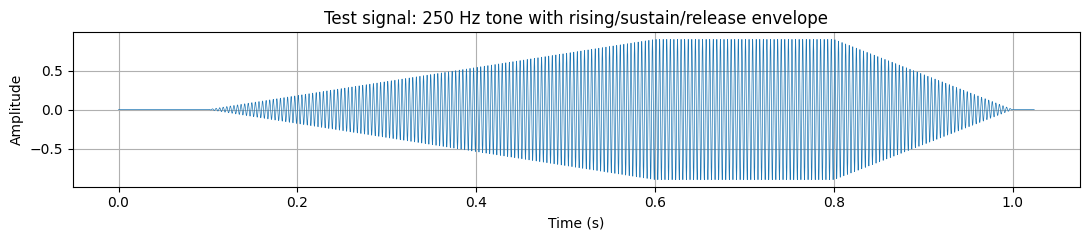

In [2]:
N = 8192
t = np.arange(N) / SAMPLE_RATE
amplitude = np.zeros(N)
# Rising envelope from t=0.1s to t=0.6s, sustain to t=0.8s, release to t=1.0s.
rising = (np.arange(N) > 0.1 * SAMPLE_RATE) & (np.arange(N) < 0.6 * SAMPLE_RATE)
sustain = (np.arange(N) >= 0.6 * SAMPLE_RATE) & (np.arange(N) < 0.8 * SAMPLE_RATE)
release = (np.arange(N) >= 0.8 * SAMPLE_RATE) & (np.arange(N) < 1.0 * SAMPLE_RATE)
amplitude[rising] = np.linspace(0.0, 0.9, rising.sum())
amplitude[sustain] = 0.9
amplitude[release] = np.linspace(0.9, 0.0, release.sum())
signal = amplitude * np.sin(2 * np.pi * 250 * t)

fig, ax = plt.subplots(figsize=(11, 2.5))
ax.plot(t, signal, linewidth=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.set_title('Test signal: 250 Hz tone with rising/sustain/release envelope')
ax.grid(True)
fig.tight_layout();

## Envelope followers

`PeakEnvelope` uses an asymmetric one-pole filter — fast attack when the input rises, slow release when it falls. `RMSEnvelope` uses a single symmetric time constant on x[n]² and reports the square root.

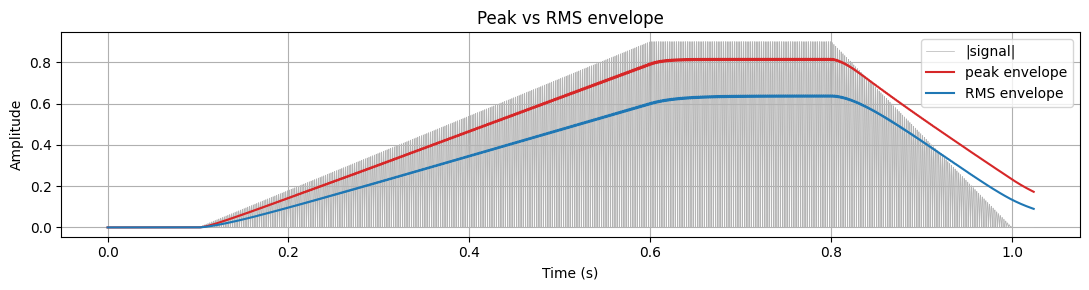

In [3]:
peak = mpdsp.PeakEnvelope(sample_rate=SAMPLE_RATE, attack_ms=5.0, release_ms=80.0)
rms  = mpdsp.RMSEnvelope(sample_rate=SAMPLE_RATE, window_ms=30.0)

peak_env = peak.process_block(signal)
rms_env  = rms.process_block(signal)

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(t, np.abs(signal), color='0.7', linewidth=0.5, label='|signal|')
ax.plot(t, peak_env, color='C3', linewidth=1.5, label='peak envelope')
ax.plot(t, rms_env, color='C0', linewidth=1.5, label='RMS envelope')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Amplitude')
ax.set_title('Peak vs RMS envelope')
ax.legend(); ax.grid(True)
fig.tight_layout();

A few observations:

- **Peak envelope** locks onto the carrier amplitude quickly (fast attack) and holds through the zero crossings of the 250 Hz tone without dipping.
- **RMS envelope** is smoother and sits at 0.9 / √2 ≈ 0.636 during the sustain — that's the RMS of an amplitude-0.9 sine.
- The release tail differs: peak releases exponentially over ~80 ms; RMS is symmetric with a ~30 ms time constant.

Use peak envelopes for gate / side-chain / clipper logic; use RMS for loudness / perceptual level.

## Compressor — hard knee vs soft knee

Compare a 4:1 compressor at a −12 dB threshold with and without a soft-knee zone. The soft knee smooths the gain transition near the threshold at the cost of some attenuation below it.

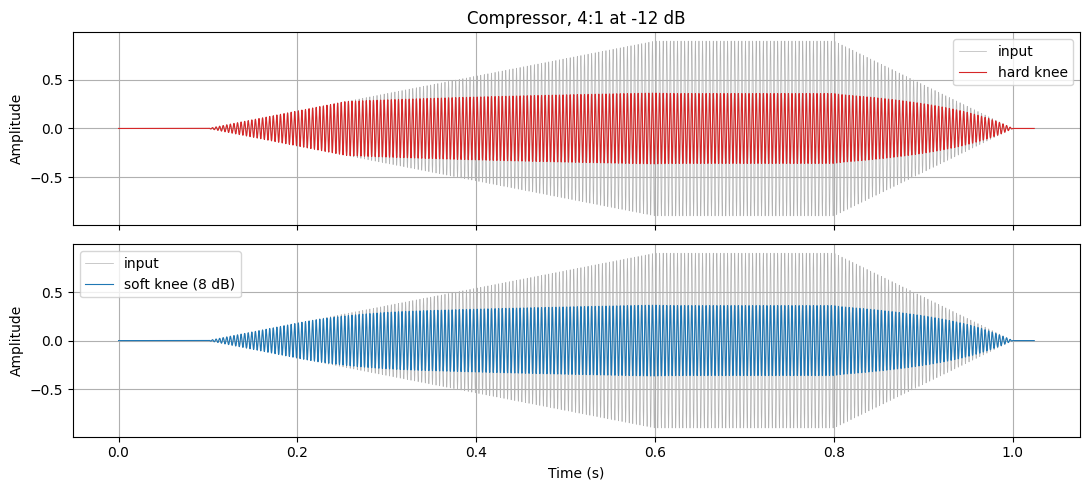

In [4]:
hard = mpdsp.Compressor(sample_rate=SAMPLE_RATE, threshold_db=-12.0, ratio=4.0,
                         attack_ms=2.0, release_ms=80.0)
soft = mpdsp.Compressor(sample_rate=SAMPLE_RATE, threshold_db=-12.0, ratio=4.0,
                         attack_ms=2.0, release_ms=80.0, knee_db=8.0)

hard_out = hard.process_block(signal)
soft_out = soft.process_block(signal)

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
axes[0].plot(t, signal, color='0.7', linewidth=0.5, label='input')
axes[0].plot(t, hard_out, color='C3', linewidth=0.8, label='hard knee')
axes[0].set_ylabel('Amplitude'); axes[0].grid(True); axes[0].legend()
axes[0].set_title('Compressor, 4:1 at -12 dB')
axes[1].plot(t, signal, color='0.7', linewidth=0.5, label='input')
axes[1].plot(t, soft_out, color='C0', linewidth=0.8, label='soft knee (8 dB)')
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Amplitude')
axes[1].grid(True); axes[1].legend()
fig.tight_layout();

## AGC — bring a quiet signal up to target

Automatic gain control with `target_level=0.5` (linear) and a generous `max_gain=100` lifts a very quiet input up to the target RMS, with the `window_ms` parameter setting how fast the gain can swing.

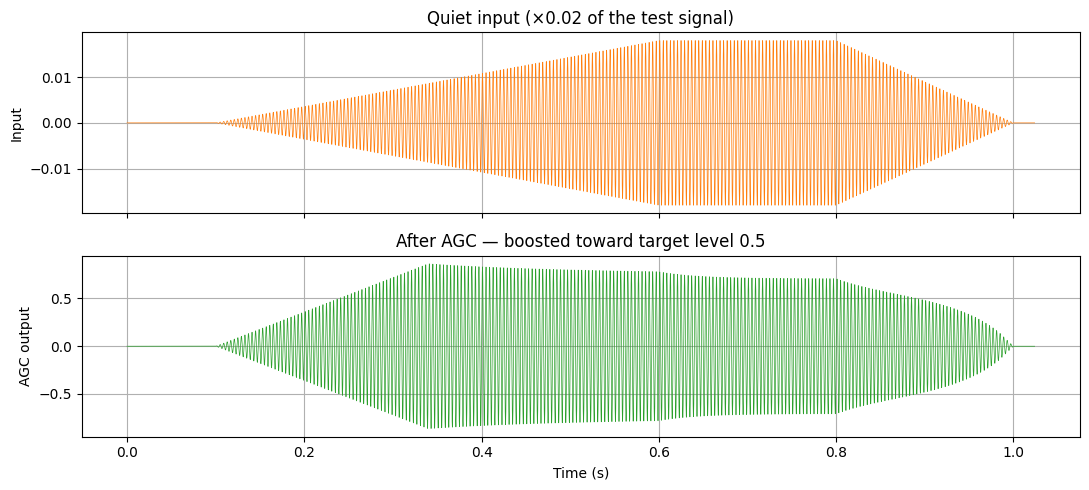

In [5]:
quiet = 0.02 * signal   # 34 dB below full scale

agc = mpdsp.AGC(sample_rate=SAMPLE_RATE, target_level=0.5,
                 window_ms=50.0, max_gain=100.0)
agc_out = agc.process_block(quiet)

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
axes[0].plot(t, quiet, color='C1', linewidth=0.5)
axes[0].set_ylabel('Input'); axes[0].set_title('Quiet input (×0.02 of the test signal)')
axes[0].grid(True)
axes[1].plot(t, agc_out, color='C2', linewidth=0.5)
axes[1].set_ylabel('AGC output'); axes[1].set_xlabel('Time (s)')
axes[1].set_title('After AGC — boosted toward target level 0.5'); axes[1].grid(True)
fig.tight_layout();

## Mixed-precision sweep

Each conditioning class takes a dtype at construction. Compare how a compressor's output evolves across the supported arithmetic configurations. With `tiny_posit` (posit<8,2>), the release-time coefficient `(1 - exp(-1/(release_ms·fs)))` is tiny enough to round to zero, so the envelope can't rise and the compressor applies no gain reduction — a precision-floor effect worth catching.

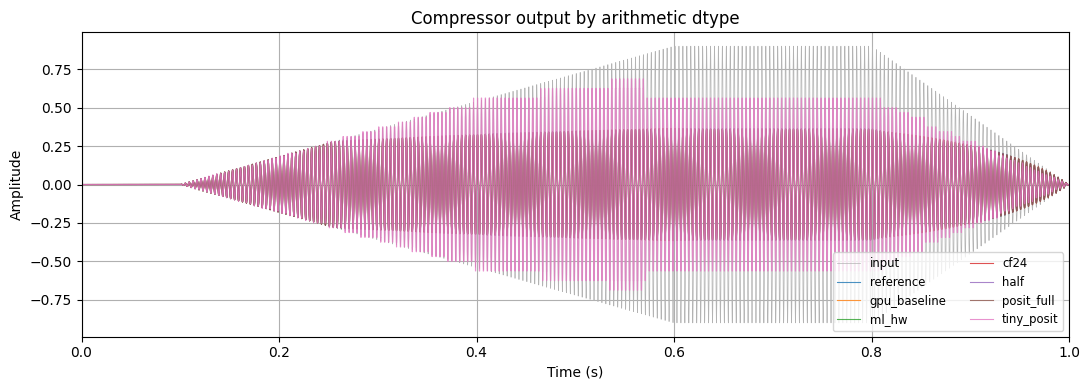

In [6]:
dtypes = ['reference', 'gpu_baseline', 'ml_hw', 'cf24', 'half', 'posit_full', 'tiny_posit']

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t, signal, color='0.7', linewidth=0.5, label='input')
for dt in dtypes:
    comp = mpdsp.Compressor(sample_rate=SAMPLE_RATE, threshold_db=-12.0,
                             ratio=4.0, attack_ms=2.0, release_ms=80.0,
                             dtype=dt)
    y = comp.process_block(signal)
    ax.plot(t, y, linewidth=0.8, label=dt, alpha=0.8)
ax.set_xlim(0.0, 1.0)
ax.set_xlabel('Time (s)'); ax.set_ylabel('Amplitude')
ax.set_title('Compressor output by arithmetic dtype')
ax.legend(loc='lower right', fontsize='small', ncol=2)
ax.grid(True)
fig.tight_layout();

Zooming in on the sustain region, the `reference` / `cf24` / `posit_full` / `half` / `gpu_baseline` / `ml_hw` outputs all track closely — the difference from reference is a few ULPs at most. `tiny_posit` is visibly identity: it never engages the compressor because the release coefficient collapses to 1.0 and the envelope stays pinned at zero.

This is the value proposition of mixed-precision research made concrete: the same high-level DSP algorithm behaves identically across several arithmetic systems, and diverges sharply at one. Knowing which one, and why, is what lets you size the arithmetic to the task.

## Takeaways

- **Peak vs RMS** is a design-time choice driven by what the consumer of the envelope cares about: peak amplitude (gates, limiters, clippers) or perceptual level (meters, AGC, compression).
- **Knee choice** trades distortion-like transition artifacts for passband uniformity. Soft knee works well for musical content; hard knee works well for brick-wall limiting.
- **Dtype matters at the coefficient level**. Release time constants expressed as `(1 - exp(-small))` are the sensitive path. The same compressor design that's exact in double and `cf24` collapses in `tiny_posit` — and that's a finding, not a bug.
- The companion notebook `06_estimation.ipynb` applies the same workflow to the estimation bindings (Kalman, LMS, RLS).